# **회귀 모델링 프로세스 이해하기**
이번 과제에선 회귀 분석과 더불어 전체적인 모델링 프로세스에 대해 이해해보겠습니다. 



### 데이터셋 설명 (```Concrete_data.csv```)
콘크리트는 건설 및 토목공학 분야에서 가장 중요한 재료 중 하나로 널리 사용됩니다. <br/> <br/>
콘크리트의 **압축강도**는 재료의 성능을 평가하는 주요 지표이며, 이는 **양생기간과 혼합에 사용되는 재료 성분**들에 따라 결정됩니다. <br/><br/>
이번 과제의 목표는 이러한 입력 변수들을 바탕으로 **콘크리트의 압축강도를 예측할 수 있는 회귀 모델을 구축**하는 것입니다.

**독립변수**  <br/><br/>
단위: kg/m³
- Cement
- Blast Furnace Slag
- Fly Ash
- Water
- Superplasticizer
- Coarse Aggregate
- Fine Aggregate


단위: 일 (1일 ~ 365일)  
- Age (양생 기간)
<br/><br/>

**종속변수**  <br/><br/>
단위: MPa (Megapascal)
- csMPa


# 1. 데이터 탐색

In [2]:
# 데이터 전처리 패키지
import numpy as np
import pandas as pd

# 데이터 시각화 패키지
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# 데이터 불러오기
data = pd.read_csv('Concrete_data.csv')

## 1.a. 데이터셋의 크기, 변수의 데이터 타입 등을 확인해줍니다.

In [4]:
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


<span style="color:red"> ***를 채워주세요 <span>

In [5]:
# 데이터셋의 크기 확인
data.shape

(1030, 9)

In [6]:
# info로 데이터 타입 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


#### 데이터의 모든 변수는 수치형 데이터(Int, Float)로 확인되며, 결측치가 존재하지 않는다. (물론 0, ? 등으로 표시된 결측치는 따로 확인해야 함!!)

## 1.b. 중복 데이터를 확인해 삭제해 줍니다.

In [7]:
# 중복 데이터 확인
dupes = data.duplicated()
print(' The number of duplicates in the dataset are:',sum(dupes), '\n')

pd.DataFrame(data[dupes])

 The number of duplicates in the dataset are: 25 



,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
100,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20
103,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
111,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
123,425.0,106.3,0.0,153.5,16.5,852.1,887.1,28,60.29


In [8]:
# 중복 열 제거하기
data.drop_duplicates(keep="first", inplace=True)

# 중복 여부 확인
dupes1 = data.duplicated()
print("The number of duplicates in the dataset are:", sum(dupes1), "\n")

The number of duplicates in the dataset are: 0 



## 1.c. EDA 

#### 데이터셋을 자유롭게 EDA해 보고, 변수들의 분포나 변수 간의 관계를 살펴본 뒤 드는 생각을 간단히 정리해 보세요. (시각화/비시각화 방법으로 각 1개 이상)

#### 필요하다면 통계적 검정을 활용해봐도 좋아요!


#### *코드 아래 정리* <span>

In [25]:
data.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [26]:
data.corr()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
cement,1.000000,-0.303324,-0.385610,-0.056625,0.060906,-0.086205,-0.245375,0.086348,0.488283
slag,-0.303324,1.000000,-0.312352,0.130262,0.019800,-0.277559,-0.289685,-0.042759,0.103374
flyash,-0.385610,-0.312352,1.000000,-0.283314,0.414213,-0.026468,0.090262,-0.158940,-0.080648
water,-0.056625,0.130262,-0.283314,1.000000,-0.646946,-0.212480,-0.444915,0.279284,-0.269624
superplasticizer,0.060906,0.019800,0.414213,-0.646946,1.000000,-0.241721,0.207993,-0.194076,0.344209
coarseaggregate,-0.086205,-0.277559,-0.026468,-0.212480,-0.241721,1.000000,-0.162187,-0.005264,-0.144717
fineaggregate,-0.245375,-0.289685,0.090262,-0.444915,0.207993,-0.162187,1.000000,-0.156572,-0.186448
age,0.086348,-0.042759,-0.158940,0.279284,-0.194076,-0.005264,-0.156572,1.000000,0.337367
csMPa,0.488283,0.103374,-0.080648,-0.269624,0.344209,-0.144717,-0.186448,0.337367,1.000000


<Axes: xlabel='age', ylabel='csMPa'>

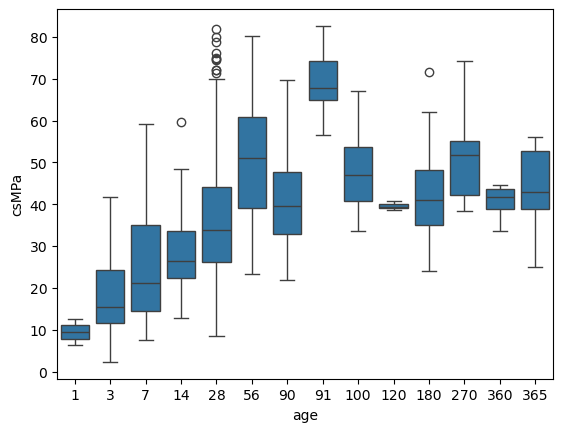

In [ ]:
from scipy import stats as spst
import seaborn as sns

sns.boxplot(data=data,x='age',y='csMPa')

### 비시각화 (describe(), corr())
- describe()
    - 혼합에 사용되는 재료의 성분들과 양생 기간, 압축 강도의 전체적인 분포를 확인할 수 있다.
    - 평균적으로 coarseaggregate가 가장 많이 사용되며, superplasticizer가 가장 적게 사용되는 것을 볼 수 있다.
    - 양생 기간은 1일에서 365일 사이로 확인된다.
- corr()
    - 변수들간의 상관관계를 확인할 수 있다.
    - 압축강도의 관점에서 봤을 때, 	cement, slag, superplasticizer, age와 양의 상관관계를 이루고, flyash, water, coarseaggregate, fineaggregate와 음의 상관관계를 이룬다.
    - 특히, superplasticizer와 water가 가장 큰 음의 상관관계를 이루기 때문에 superplasticizer를 넣으면 넣어야할 물의 양을 감소시킬 수 있지 않을까 생각해볼 수 있다.	

### 시각화 (boxplot)
- 양생 기간이 길면 당연히 압축 강도도 커질 것이라 예상했고, 그래프로 보니 예상과 비슷하게 전체적으로 양생기간이 길어지면 압축강도도 커지는 것을 볼 수 있다.
- 그치만 특히 28일 기준으로 이상치가 굉장히 많이 보이고, 56일 후를 기준으로는 양생기간과 압축강도의 관계를 한눈에 정의내리기는 힘들다.  
    -> 구글링 결과, 일반적으로 28일의 양생 기간이 가장 효율적인 기준으로 평가된다고 한다.

# 2. 피처 엔지니어링

In [29]:
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2.a. 변수의 생성 및 삭제
### 2.a.i. 파생변수 생성

콘크리트 내구성의 핵심 요소는 **물과 시멘트 비율**입니다.<br>
따라서 파생변수 생성을 통해 새로운 칼럼을 생성해 봅시다.

In [30]:
data['w/c ratio'] = data['water'] / data['cement']

In [31]:
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,w/c ratio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767


### 2.a.ii. 차원 축소(PCA) 및 스케일링

이번 과제에선 차원 축소 기법으로 PCA를 활용해보겠습니다.

우리의 전략은 다음과 같아요.

- 모델 1: 모든 변수를 그대로 사용하여 학습

- 모델 2: PCA를 이용해 차원을 축소한 후 학습


이 두 모델을 비교 분석한 뒤 차원 축소를 적용한 모델이 더 적합한지, 원본 변수를 유지한 모델이 더 적합한지를 판단하여 최종적으로 성능이 좋은 모델을 체택할 예정입니다.

In [32]:
# 데이터를 변형시킬 땐 원본 데이터를 보존하기 위해 복사본 생성하는 것이 좋아요.
data1 = data.copy()

In [34]:
import scipy.stats as stats
from scipy.stats import zscore
from sklearn.decomposition import PCA

# Z-score 표준화로 적용하여 스케일링
data_scaled = data1.apply(zscore)

# 종속변수 'csMPa'를 제외하고 독립변수만 추출
X_scaled=data_scaled.drop('csMPa', axis=1) # 열 drop을 어떻게 했었죠?

#### PCA 모델로 우선 8개의 주성분을 추출한 후, 최종적으로는 95% 누적 분산을 설명하는 개수로 확정 예정입니다

In [35]:
pca = PCA(n_components=8)

# 스케일링된 데이터에 PCA 모델 학습
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

PCA 진행 후 아래와 같이 고유값과 설명된 분산 비율을 확인할 수 있어요.

In [36]:
# Eigen Values
# 각 주성분이 설명하는 분산의 크기를 의미합니다.
# 값이 클수록 해당 주성분이 데이터의 정보(분산)를 많이 담고 있음을 뜻해요.

print(pca.explained_variance_)

[2.35316571 2.20985408 1.35277753 1.02291423 0.96645795 0.79209809
 0.19820651 0.08363247]


In [37]:
# Eigen Vectors
print(pca.components_)

[[-1.91956842e-01  3.15463386e-01 -2.66457387e-01  5.52815981e-01
  -4.74419640e-01 -2.87045612e-02 -3.06395895e-01  2.18768968e-01
   3.45534545e-01]
 [ 6.09516383e-01 -1.85480511e-01 -3.81625638e-01  1.14256362e-01
  -1.67602503e-01  8.08865928e-02 -2.53164742e-01  2.01017818e-01
  -5.44298012e-01]
 [-1.79077899e-01 -5.56006083e-01  2.05489283e-01  1.27523384e-02
  -3.73725305e-01  6.75959654e-01  5.79925225e-02  1.04295947e-01
   7.46125950e-02]
 [-2.26524583e-02  4.11333899e-01 -1.71094843e-01 -2.67508381e-01
   4.10365454e-02  5.31672685e-01 -4.17497359e-01 -5.19332639e-01
  -3.29671610e-02]
 [-4.33887038e-02  3.61102747e-02 -6.02576514e-01 -1.21302891e-01
  -3.04347560e-01  1.54516771e-02  6.76185907e-01 -2.61660278e-01
   2.09987515e-02]
 [-1.43248979e-01  3.03417985e-01 -2.19966196e-01 -3.78849861e-01
   2.21904959e-01  2.83316773e-01  9.23299402e-02  7.46436531e-01
   1.73894994e-02]
 [-4.64352337e-03 -3.00174596e-01 -3.97557996e-01  4.25015686e-01
   6.70149161e-01  2.1634659

각 주성분이 데이터를 얼마나 설명하고 있는지 분산 비율을 확인해보겠습니다.

In [38]:
print(pca.explained_variance_ratio_)

[0.26120269 0.24529502 0.15015905 0.11354404 0.10727737 0.08792333
 0.02200103 0.00928325]


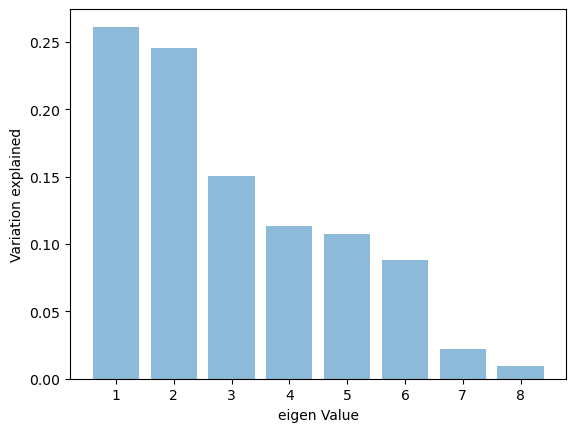

In [39]:
# 주성분 별 설명분산 비율 시각화
plt.bar(list(range(1,9)),pca.explained_variance_ratio_,alpha=0.5, align='center')
plt.ylabel('Variation explained')
plt.xlabel('eigen Value')
plt.show()

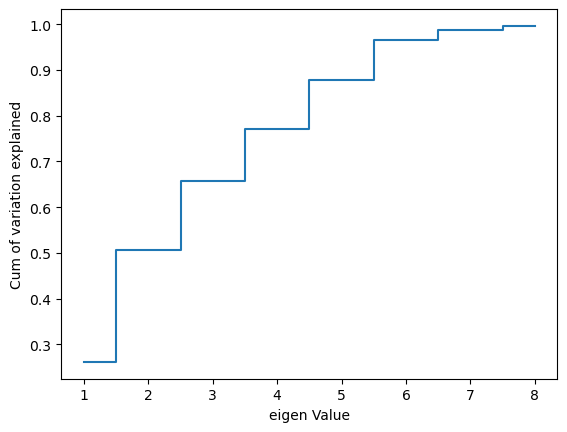

In [40]:
# 누적 설명분산 비율 시각화
plt.step(list(range(1,9)),np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Cum of variation explained')
plt.xlabel('eigen Value')
plt.show()

In [41]:
# 각 주성분을 추가했을 때 전체 분산을 몇 %까지 설명할 수 있는지를 계산
cum_var_exp = np.cumsum(pca.explained_variance_ratio_)
# print("Cumulative Variance Explained", cum_var_exp)
pd.DataFrame(cum_var_exp,columns=['Cumul Variance Explanation'],index=['1','2','3','4','5','6','7','8'])

,Cumul Variance Explanation
1,0.261203
2,0.506498
3,0.656657
4,0.770201
5,0.877478
6,0.965402
7,0.987403
8,0.996686


#### # 6개의 주성분이 95% 이상의 분산을 설명하므로 6개를 선택해 다시 PCA를 진행할게요!

In [42]:
pca6 = PCA(n_components=6)
pca6.fit(X_scaled)
print(pca6.components_)
print(pca6.explained_variance_ratio_)


Xpca6 = pca6.transform(X_scaled)
Y = data_scaled['csMPa']

[[-0.19195684  0.31546339 -0.26645739  0.55281598 -0.47441964 -0.02870456
  -0.30639589  0.21876897  0.34553455]
 [ 0.60951638 -0.18548051 -0.38162564  0.11425636 -0.1676025   0.08088659
  -0.25316474  0.20101782 -0.54429801]
 [-0.1790779  -0.55600608  0.20548928  0.01275234 -0.3737253   0.67595965
   0.05799252  0.10429595  0.0746126 ]
 [-0.02265246  0.4113339  -0.17109484 -0.26750838  0.04103655  0.53167269
  -0.41749736 -0.51933264 -0.03296716]
 [-0.0433887   0.03611027 -0.60257651 -0.12130289 -0.30434756  0.01545168
   0.67618591 -0.26166028  0.02099875]
 [-0.14324898  0.30341798 -0.2199662  -0.37884986  0.22190496  0.28331677
   0.09232994  0.74643653  0.0173895 ]]
[0.26120269 0.24529502 0.15015905 0.11354404 0.10727737 0.08792333]


# 3. 모델 생성

#### 모델을 만들기 전에 PCA 변환된 데이터(Xpca6)와 타깃값(Y)을 학습/테스트 데이터셋으로 분리해야겠죠?

test_size=0.20 → 데이터의 20%를 테스트 데이터로 사용합니다.

<span style="color:red"> ***를 채워주세요 <span>

In [58]:
# 기계학습 모델 구축 및 평가 패키지
import scipy as sp
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(Xpca6, Y, test_size=0.20, random_state=1415)

PCA를 하지 않은 데이터에 대해서도 스케일링 후 학습/테스트셋으로 나눠줍니다.

In [44]:
data_scaled = data1.apply(zscore)

X = data_scaled.drop('csMPa', axis=1) # 종속변수 열 제외 axis = ?
y = data_scaled['csMPa']

# 특히 정규화 모델(Ridge, Lasso)은 변수 크기에 따라 가중치 패널티가 달라져서 스케일링이 반드시 필요합니다.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1415)

### **참고 )** 피쳐 스케일(단위)의 영향 <br/>
10 kg/m³와 10일은 전혀 다른 의미를 가지지만, 모델은 두 값을 단순히 숫자 10으로 인식하여 동일한 수준의 중요도로 처리합니다.


#### ✅ 스케일의 영향을 받는 알고리즘

**경사 하강법 기반 알고리즘**

- 선형 회귀 (Linear Regression)

- 로지스틱 회귀 (Logistic Regression)

**거리 기반 알고리즘**

- K-최근접 이웃 (KNN)

- K-Means 군집화 (K-Means)

- 서포트 벡터 머신 (SVM)

👉 표준화(Standardization) 또는 정규화(Normalization) 등의 스케일링 전처리 과정이 매우 중요


#### ✅ 스케일(단위)의 영향을 받지 않는 알고리즘

- 트리 기반 알고리즘

- 결정 트리 (Decision Tree)

- 랜덤 포레스트 (Random Forest)

- 그래디언트 부스팅 (XGBoost, LightGBM 등)

👉 트리 기반 모델은 변수의 분할 기준이 상대적이기 때문에, 절대적인 숫자의 크기나 단위는 모델 성능에 영향을 주지 않음

## 3.a. 모델 결정

1. **선형회귀**
- 우선 가장 기본적인 기준 모델(Baseline)인 선형회귀(Linear Regression)부터 시작할게요. 
- 모델 성능을 비교하는 출발점이 되어줄 수 있어요.

2. **정규화 회귀 기법**
- Ridge Regression (L2 규제)
- Lasso Regression (L1 규제)
    → 다중공선성 문제 완화, 불필요한 변수 축소가 가능합니다.

### 3.a.1. Regression Model 1: Linear Regression

#### 모델 객체 생성, 학습

<span style="color:red"> ***를 채워주세요 <span>

In [46]:
from sklearn.linear_model import LinearRegression

# 1. 선형 회귀 모델 객체를 생성합니다.
regression_model = LinearRegression()

# 2. 학습 데이터를 사용해 모델을 학습(fit)시킵니다.
regression_model.fit(X_train, y_train)

# 3. 테스트 데이터를 이용해 predict하고 y_pred에 저장합니다.
y_pred = regression_model.predict(X_test)

In [47]:
# 참고
# 회귀 계수(coefficient): 각 독립변수가 종속변수에 미치는 영향력의 크기와 방향을 나타냅니다.

for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

# 절편(intercept): 회귀선이 y축과 만나는 지점
intercept = regression_model.intercept_
print("The intercept for our model is {}".format(regression_model.intercept_))

The coefficient for cement is 0.6745255108499502
The coefficient for slag is 0.5713052044526022
The coefficient for flyash is 0.3819965177593877
The coefficient for water is -0.14824101300142628
The coefficient for superplasticizer is 0.07998600381906654
The coefficient for coarseaggregate is 0.0777804095715215
The coefficient for fineaggregate is 0.13618215690146543
The coefficient for age is 0.45032398935573753
The coefficient for w/c ratio is -0.11792397833239487
The intercept for our model is -0.00898128480500016


#### 모델 평가 (MSE,MAE,R2값 출력)

In [59]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("r2_score:", r2)

MSE: 0.37030436469318695
MAE: 0.46971068687019046
r2_score: 0.6322017000040039


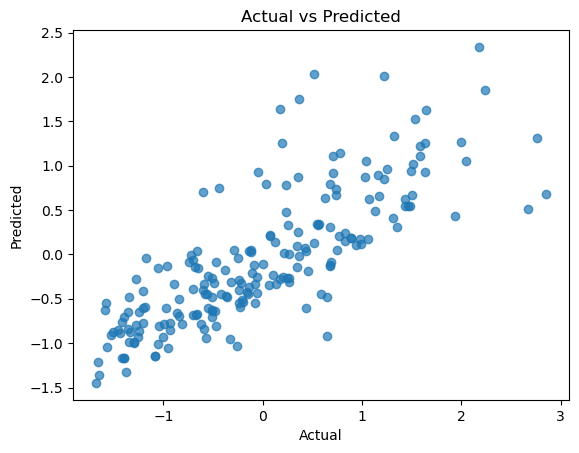

In [49]:
# 시각화로 예측과 실제 데이터 비교하기
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

#### 차원 축소된 데이터에 대해서도 반복해줄게요!

In [50]:
# 모델 학습
regression_model_pca = LinearRegression()
regression_model_pca.fit(X_train_pca, y_train_pca)

# 테스트 데이터에 대한 예측값 계산
y_pred_pca = regression_model_pca.predict(X_test_pca)

# 모델 평가
mse_pca = mean_squared_error(y_test_pca, y_pred_pca)
mae_pca = mean_absolute_error(y_test_pca, y_pred_pca)

'''
r2_score의 경우 위에 두 줄로 작성했던 코드를 한 줄로 대체 가능해요!
y_pred = regression_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

'''
r2_pca = regression_model_pca.score(X_test_pca, y_test_pca)

print("MSE:", mse_pca)
print("MAE:", mae_pca)
print("r2_score:", r2_pca)

MSE: 0.3723960658671219
MAE: 0.4914570627171401
r2_score: 0.6301241545867082


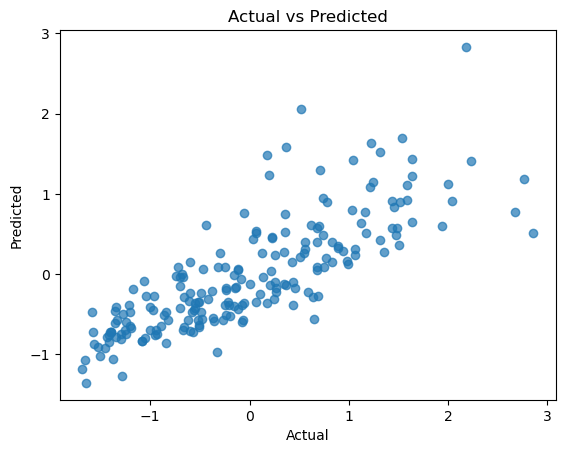

In [51]:
# 시각화로 예측과 실제 데이터 비교하기
plt.scatter(y_test_pca, y_pred_pca, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### Regression Model 2: Ridge Regression: Regularised Linear Model

In [52]:
# 모든 변수에 대해 모델 생성
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.3) # 객체 생성
ridge.fit(X_train,y_train) # 학습
y_pred_ridge = ridge.predict(X_test) # 예측

# 모델 평가 
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MSE:", mse_ridge)
print("MAE:", mae_ridge)
print("r2_score:", r2_ridge)

MSE: 0.3700745751927649
MAE: 0.46971366648570545
r2_score: 0.6324299343854218


In [53]:
# PCA 데이터에 대해 모델 생성
ridge_pca = Ridge(alpha=0.3) # 객체 생성
ridge_pca.fit(X_train_pca, y_train_pca) # 학습
y_pred_ridge_pca = ridge_pca.predict(X_test_pca) # 예측

# 모델 평가 
mse_ridge_pca = mean_squared_error(y_test_pca, y_pred_ridge_pca)
mae_ridge_pca = mean_absolute_error(y_test_pca, y_pred_ridge_pca)
r2_ridge_pca = r2_score(y_test_pca, y_pred_ridge_pca)

print("MSE:", mse_ridge_pca)
print("MAE:", mae_ridge_pca)
print("r2_score:", r2_ridge_pca)

MSE: 0.37242947170692947
MAE: 0.4914899075721871
r2_score: 0.6300909748236196


### Regression Model 3: Lasso Regression - Regularised Linear Model

In [54]:
# 모든 변수에 대해 모델 생성
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1) # 객체 생성
lasso.fit(X_train,y_train) # 학습
y_pred_lasso = lasso.predict(X_test) # 예측

# 모델 평가 
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MSE:", mse_lasso)
print("MAE:", mae_lasso)
print("r2_score:", r2_lasso)

MSE: 0.46505973545243373
MAE: 0.5513413424665261
r2_score: 0.538087593869671


In [55]:
# PCA 데이터에 대해 모델 생성
lasso_pca = Lasso(alpha=0.1) # 객체 생성
lasso_pca.fit(X_train_pca,y_train_pca) # 학습
y_pred_lasso_pca = lasso_pca.predict(X_test_pca) # 예측

# 모델 평가 
mse_lasso_pca = mean_squared_error(y_test_pca, y_pred_lasso_pca)
mae_lasso_pca = mean_absolute_error(y_test_pca, y_pred_lasso_pca)
r2_lasso_pca = r2_score(y_test_pca, y_pred_lasso_pca)

print("MSE:", mse_lasso_pca)
print("MAE:", mae_lasso_pca)
print("r2_score:", r2_lasso_pca)

MSE: 0.43712591676162504
MAE: 0.5399918234135478
r2_score: 0.5658323681863018


# 4. 모델 성능 평가

In [56]:
summary = {'Score': [r2,r2_ridge, r2_lasso],
            'Score for 6PCA model': [r2_pca,r2_ridge_pca,r2_lasso_pca]
            }

models=['Linear Regression','Ridge','Lasso']
sum_df = pd.DataFrame(summary,models)

In [57]:
sum_df

,Score,Score for 6PCA model
Linear Regression,0.632202,0.630124
Ridge,0.632430,0.630091
Lasso,0.538088,0.565832


(참고) summary()가 필요하다면 statsmodels의 OLS를 사용할 수 있지만, statsmodels에는 Lasso가 직접 구현되어 있지 않아요.

## 가장 성능이 좋은 모델을 아래 적어주세요!  

Ridge 모델이 0.632430의 r2 값으로 가장 성능이 좋긴 하지만 선형회귀 모델이나 PCA를 적용한 선형회귀 및 Ridge 모델의 성능이 비슷하다고 볼 수 있다.

# 5. 모델 성능 개선

불필요한 변수를 제거하거나 하이퍼파라미터 튜닝을 통해 모델 성능을 개선하고, 필요 시 모델을 변경하여 처음부터 다시 진행합니다.

In [37]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GridSearchCV

# 참고) 해당 모델에 대해 GridSearch를 통해 최적의 하이파라미터를 찾아 model을 개선시켜 봅시다.
alphas = np.logspace(-4, 4, 50)  # alpha 후보들

ridge = Ridge()
ridge_params = {'alpha': alphas}

ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

print("📌 Ridge Best alpha:", ridge_grid.best_params_['alpha'])
print("📉 Ridge Best MSE:", -ridge_grid.best_score_)

📌 Ridge Best alpha: 2.559547922699533
📉 Ridge Best MSE: 0.41539897781524804


## 끝!
... 나기 전에 전체적인 회귀 분석 프로세스(순서)에 대해 간단히 적어보며 마칩시다...

- 예측하고자 하는 문제를 정의내리고 데이터를 수집, 탐색, 전처리(스케일링, PCA 등)를 한다. 데이터를 train / test 로 나누고 회귀 모델을 이용해 데이터를 학습시킨다. 마지막으로 $R^2$, MSE, MAE 등을 통해 모델의 성능을 평가한다

# 진짜 과제 끝!! 수고하셨습니다~:)